In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as pl
import astropy.constants as c
import astropy.units as u
freq_low = 3.29e15 * u.Hz
freq_high = 1.50e16 * u.Hz
quanta = c.h * (freq_low + freq_high) / 2
quokka_csv_path = '../../../tests/photoionization_quokka_output.csv'
julia_csv_path = './photoionization-julia/with_energy.csv'
df_quokka = pd.read_csv(quokka_csv_path, delimiter=',')
df_julia = pd.read_csv(julia_csv_path, delimiter=',')
def get_error(key):
    return np.sum(np.abs(df_julia[key] - df_quokka[key]) / df_julia[key]) / len(df_julia)

In [11]:
get_error('n_e'), get_error('n_HI'), get_error('n_HII'), get_error('n_gamma'), get_error('Egas')

(np.float64(2.269152330611286e-08),
 np.float64(1.0050859399812925e-07),
 np.float64(2.269152865356852e-08),
 np.float64(3.580706969598308e-10),
 np.float64(2.2681551065441488e-08))

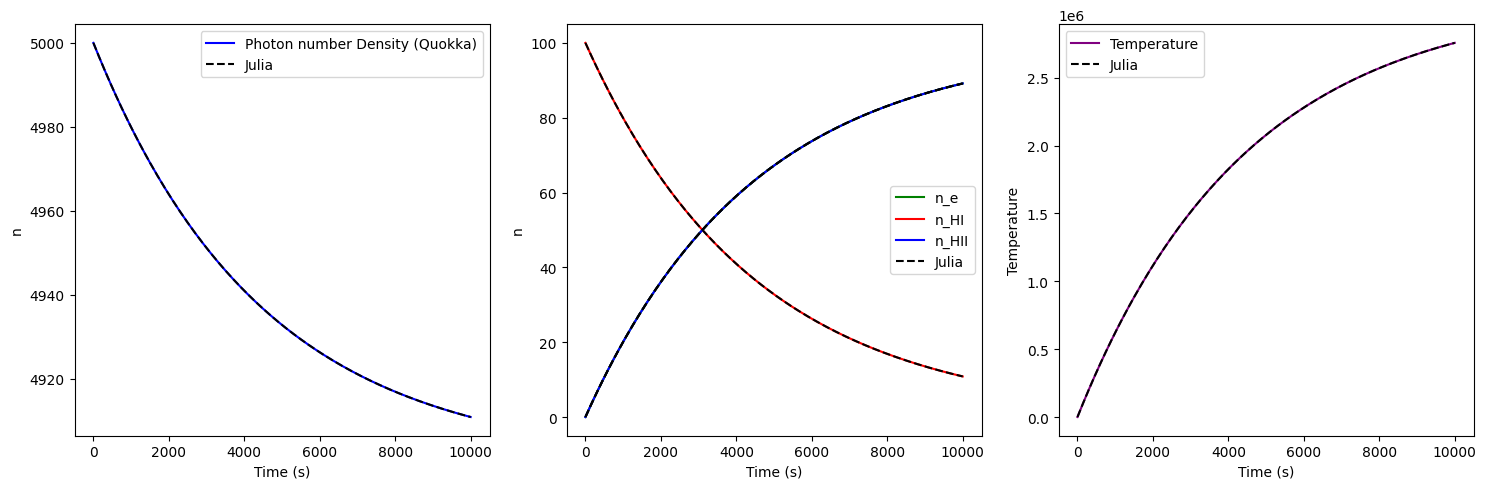

In [12]:
fig, ax = pl.subplots(1, 3, figsize=(15, 5))
ax[0].plot(df_quokka["time"], df_quokka["n_gamma"], label="Photon number Density (Quokka)", color="blue")
ax[0].plot(df_julia["time"], df_julia["n_gamma"], label="Julia", linestyle="dashed", color="black")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("n")
ax[0].legend()
ax[1].plot(df_quokka["time"], df_quokka["n_e"], label="n_e", color="green")
ax[1].plot(df_quokka["time"], df_quokka["n_HI"], label="n_HI", color="red")
ax[1].plot(df_julia["time"], df_julia["n_HI"], color="black", linestyle="dashed")
ax[1].plot(df_quokka["time"], df_quokka["n_HII"], label="n_HII", color="blue")
ax[1].plot(df_julia["time"], df_julia["n_HII"], color="black", linestyle="dashed")
ax[1].plot(df_julia["time"], df_julia["n_e"], label="Julia", color="black", linestyle="dashed")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("n")
ax[1].legend()
ax[2].plot(df_quokka["time"], df_quokka["gas_temp"], label="Temperature", color="purple")
ax[2].plot(df_julia["time"], df_julia["gas_temp"], label="Julia", color="black", linestyle="dashed")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Temperature")
ax[2].legend()
fig.tight_layout()